In [1]:
from astropy.table import Table
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

sources = Table.read("../outputs/tables/detected_sources.ecsv")
refcat = Table.read("../outputs/tables/reference_catalog.ecsv")

sources

from pathlib import Path

session_dir = Path("../data/raw/v854_cen_dasch")

fits_files = list(session_dir.rglob("*.fits"))
fits_files[:5]
cutout_path = fits_files[0]
cutout_path
hdul = fits.open(cutout_path)
data = hdul[0].data
wcs = WCS(hdul[0].header)

x = sources["xcentroid"]
y = sources["ycentroid"]

detected_coords = wcs.pixel_to_world(x, y)
detected_coords

catalog_coords = refcat["pos"]
catalog_coords

idx, sep2d, _ = detected_coords.match_to_catalog_sky(catalog_coords)

matches = refcat[idx]
sep2d

for i in range(len(sources)):
    print(
        i,
        "x=", sources["xcentroid"][i],
        "y=", sources["ycentroid"][i],
        "inst_mag=", sources["inst_mag"][i],
        "catalog_mag=", matches["stdmag"][i],
        "sep=", sep2d[i].arcsec, "arcsec"
    )

0 x= 685.5339805906955 y= 254.67760435739888 inst_mag= -10.700819 catalog_mag= 17.79 sep= 21.379769431716053 arcsec
1 x= 430.9844492651475 y= 477.64977692090014 inst_mag= -11.178266 catalog_mag= 18.95 sep= 9.71476956800865 arcsec


In [2]:
zp = matches["stdmag"] - sources["inst_mag"]

zp

import numpy as np

mean_zp = np.mean(zp)
std_zp = np.std(zp)

print("Mean zeropoint:", mean_zp)
print("Scatter:", std_zp)


Mean zeropoint: 29.30954360961914
Scatter: 0.8187227249151062


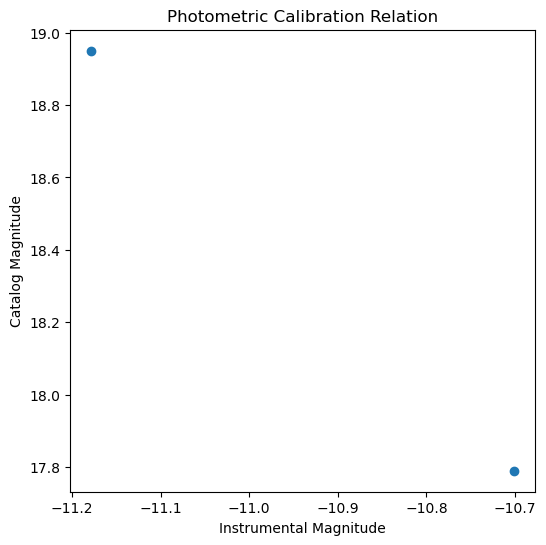

In [3]:
plt.figure(figsize=(6,6))

plt.scatter(
    sources["inst_mag"],
    matches["stdmag"]
)

plt.xlabel("Instrumental Magnitude")
plt.ylabel("Catalog Magnitude")

plt.title("Photometric Calibration Relation")

plt.show()

In [7]:
from photutils.detection import DAOStarFinder
from astropy.stats import sigma_clipped_stats

mean, median, std = sigma_clipped_stats(data, sigma=3.0)

daofind = DAOStarFinder(
    fwhm=3.0,
    threshold=4.0 * std
)

sources = daofind(data - median)

print(sources)
print(len(sources))

 id     xcentroid          ycentroid      ...   flux     mag      daofind_mag 
--- ------------------ ------------------ ... ------- ---------- -------------
  1  6.513303146970675 0.5686849711152004 ...  9740.0  -9.971397   -0.06588252
  2 42.359248141636876 158.80185198173805 ... 16825.0 -10.564888  -0.022730693
  3  395.7855003510834 176.95275976057397 ... 17335.0  -10.59731  -0.027752362
  4  685.5145493036235 254.65966146987708 ... 19069.0 -10.700819   -0.24963355
  5 257.05722070072244 296.96828614205924 ... 16243.0 -10.526666   -0.03282199
  6  221.5248897998994  390.3106554368038 ... 13441.0 -10.321079   -0.06252722
  7   404.433591739806   419.229716282741 ...  5976.0  -9.441027 -0.0078098564
  8 247.16502603335869  423.6245756059769 ... 19779.0 -10.740511 -0.0033604878
  9 326.56468639344337 473.67165003317643 ... 19988.0 -10.751924   -0.11219379
 10  430.9924608932759 477.65582468447803 ... 29601.0 -11.178266   -0.23816392
 11  635.2981370753992  626.1664747893908 ... 28826.

Matches under 25 arcsec: 11
3 x= 685.5145493036235 y= 254.65966146987708 inst_mag= -10.700819 catalog_mag= 17.79 sep= 21.34411392733167
4 x= 257.05722070072244 y= 296.96828614205924 inst_mag= -10.526666 catalog_mag= 16.49 sep= 18.363315359831176
5 x= 221.5248897998994 y= 390.3106554368038 inst_mag= -10.321079 catalog_mag= 18.77 sep= 8.137555560053885
6 x= 404.433591739806 y= 419.229716282741 inst_mag= -9.441027 catalog_mag= 16.07 sep= 17.66516378592888
7 x= 247.16502603335869 y= 423.6245756059769 inst_mag= -10.740511 catalog_mag= 16.13 sep= 11.529613009050182
8 x= 326.56468639344337 y= 473.67165003317643 inst_mag= -10.751924 catalog_mag= 18.65 sep= 17.961507863200293
9 x= 430.9924608932759 y= 477.65582468447803 inst_mag= -11.178266 catalog_mag= 18.95 sep= 9.729154659014013
10 x= 635.2981370753992 y= 626.1664747893908 inst_mag= -11.149462 catalog_mag= 18.51 sep= 22.765399552462565
11 x= 276.308046689044 y= 628.4929358123111 inst_mag= -10.768419 catalog_mag= 15.26 sep= 18.620777125036838

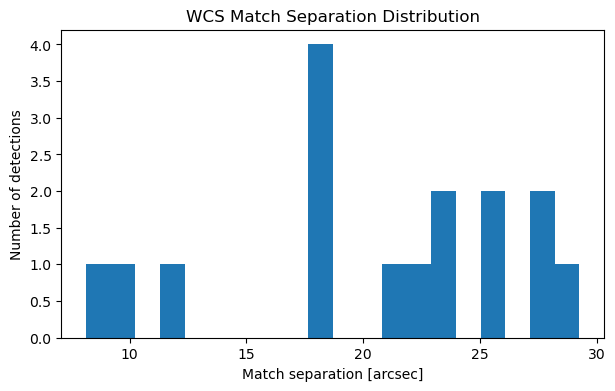

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Loosen the matching radius so we can inspect whether WCS is offset
good = sep2d.arcsec < 25

print("Matches under 25 arcsec:", good.sum())

for i in np.where(good)[0]:
    print(
        i,
        "x=", sources["xcentroid"][i],
        "y=", sources["ycentroid"][i],
        "inst_mag=", sources["mag"][i],
        "catalog_mag=", matches["stdmag"][i],
        "sep=", sep2d[i].arcsec
    )

# Plot separation distribution
plt.figure(figsize=(7,4))
plt.hist(sep2d.arcsec, bins=20)
plt.xlabel("Match separation [arcsec]")
plt.ylabel("Number of detections")
plt.title("WCS Match Separation Distribution")
plt.show()